https://colab.research.google.com/drive/1VZz5i2jH6dfBkwwaO5ipyT5nJHNpNl1O?usp=sharing

https://colab.research.google.com/drive/1QcKK6m3mbQjWns-SlYPBVvg1Pze2SjEY?usp=sharing#scrollTo=fiiWnrbGRF7a

https://colab.research.google.com/drive/1bZJ9OE7YEWkK3owKpP12Qc-RfOKeeXf2?usp=sharing#scrollTo=hyfMSBBlgn56

https://huggingface.co/cointegrated/rubert-tiny2

https://huggingface.co/tbs17/MathBERT/blob/main/README.md

<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
from transformers import BertTokenizer, BertModel

from typing import Union
import torch.nn as nn

from tqdm.auto import tqdm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


In [ ]:
from IPython.display import clear_output

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# !pip install pandas openpyxl

In [ ]:
### This is just an interface example. You may change it if you want.

class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: Union[str, nn.Module]):
      super().__init__()
      self.cnt_class = 7
      if base_transformer_model == "cointegrated/rubert-tiny2":
          self.backbone = AutoModel.from_pretrained(base_transformer_model, output_attentions=True)
          self.hid_dim = 312
      elif base_transformer_model == 'tbs17/MathBert':
          self.backbone = BertModel.from_pretrained(base_transformer_model, output_attentions=True)
          self.hid_dim = 768 #original BERT
      else:
          raise ValueError(f"Unsupported transformer model: {base_transformer_model}")
          # YOUR CODE: create additional layers for classfication
      self.classification = nn.Linear(self.hid_dim, self.cnt_class)
      self.softmax = nn.Softmax(dim=-1)

    def forward(self, **inputs): #mask=mask
        # YOUR CODE: propagate inputs through the model. Return dict with logits
        bkb = self.backbone(**inputs) #, attention
        attention = bkb.attentions
        last_hidden_state = bkb.last_hidden_state  # shape: [batch_size, seq_len, hidden_dim]
        cls_embedding = last_hidden_state[:, 0, :]
        logits = self.classification(cls_embedding)
        #probs = self.softmax(logits)

        #outputs = {"logits": logits} #{<YOUR CODE>} , "probs": probs
        return logits, attention #outputs # YOUR CODE

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [ ]:
def freeze_backbone_function(model: TransformerClassificationModel):
  if hasattr(model, 'backbone'):
    for p in model.backbone.parameters():
      p.requires_grad = False
  else:
      raise AttributeError("The model does not have a 'backbone' attribute.")
  return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [ ]:
import pandas as pd

df_ru = pd.read_excel('data_problems.xlsx')
df_en = pd.read_excel('data_problems_translated.xlsx')

In [ ]:
# для удобства назову колонки на английском, чтобы названия были одинаковыми вне зависимости от языка датасета
df_ru.rename(columns={'Задача': 'problem_text', 'Тема': 'topic'}, inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

labels2ids = {}
ids2labels = {}
datasets = {}
for language, df in zip(("ru","en"), (df_ru, df_en)):

  label_list = sorted(df["topic"].unique())  # get unique string labels
  labels2ids[language] = {label: idx for idx, label in enumerate(label_list)}
  ids2labels[language] = {v: k for k, v in labels2ids[language].items()}  # optional reverse mapping

  df["topic"] = df["topic"].map(labels2ids[language])
  train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["topic"]
  )
  datasets[language] = {"train": train_df, "val": val_df}

In [ ]:
max_lengths = []
for language in ("ru", "en"):
  for mode in ("train", "val"):
    max_lengths.append(max(len(str(i).split()) for i in list(datasets[language][mode]["problem_text"])))

max_length = max(max_lengths)
max_length

498

Выберу по 3 наиболее коротких задачи из каждого сета, чтобы карты внимания были не слишком большими

In [ ]:
min_lengths = {}
for language in ("ru", "en"):
  for mode in ("train", "val"):
    df = datasets[language][mode]
    df["index"] = [i for i in range(len(df))]
    # в датасете не все задачи корректны, некоторые являются продукатами избыточного разбиения,
    # так что пришлось выставить порог длины задач для отбора на 50 символов
    df['len'] = df["problem_text"].apply(lambda x: len(str(x)) if len(str(x)) > 50 else 10000)
    df = df.nsmallest(3, 'len', keep='first')
    min_lengths.setdefault(language, {})
    min_lengths[language].setdefault(mode, []).append(df)

In [ ]:
for language in ("ru", "en"):
  for mode in ("train", "val"):
    print(min_lengths[language][mode][0].loc[:, ["problem_text", "index"]])

                                           problem_text  index
2677  Найдите остаток от деления на 17 числа  21999 ...    343
1983  План города имеет схему, изображенную на рисун...    428
2886  Сумма  31974 + 51974  делится на 13. Докажите ...   1918
                                           problem_text  index
1869  б) Тот же вопрос для решётки 5×5 (всего 36 узл...    652
3372  p,  4p² + 1  и  6p² + 1  – простые числа. Найд...    399
3386  Решить в целых числах уравнение  x³ + 21y² + 5...    461
                                           problem_text  index
2727  Prove that 22n-1 + 3n + 4 is divided by 9 in a...     16
350   Prove the inequality sinn2x + (sinnx – cosnx)2...     43
2399  How many ways can we break up 14 people into p...     68
                                           problem_text  index
3390  n is the natural number, n ≥ 4. Prove that n! ...    681
3283  Place P(x+3) in degrees x where P(x) = x4 – x3...    798
1956  Prove what (bc, ac, ab) is divided into (a, b,...

Для удобства собрал список из 4-х коротких задач, на которых будет удобно показывать карты внимания.

In [ ]:
short_tasks = {"ru": ('Найдите остаток от деления на 17 числа  21999 + 1. ', 'Решить в целых числах уравнение  x³ + 21y² + 5 = 0. '),
               "en": ('Prove the inequality sinn2x + (sinnx – cosnx)2 ≤ 1.', 'How many ways can we break up 14 people into pairs?')}

In [ ]:
from torch.utils.data import Dataset

class ExcelTextDataset(Dataset):
    def __init__(self, dataframe, tokenizer, label_col='topic', text_col='problem_text', max_length=max_length, device=device):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.label_col = label_col
        self.text_col = text_col
        self.max_length = max_length
        self.device = device

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = str(self.data.iloc[idx][self.text_col])
        label = int(self.data.iloc[idx][self.label_col])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        item = {key: val.squeeze(0).to(device) for key, val in encoding.items()}
        item['labels'] = torch.tensor(label).to(device)
        return item

In [ ]:
from torch.utils.data import DataLoader

dataloaders = {}
datasets_tk = {}
for language in datasets.keys():
  tokenizers = {'ru': AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2"),
                "en": BertTokenizer.from_pretrained('tbs17/MathBERT', output_hidden_states=True)}
  dataloaders[language] = {}
  datasets_tk[language] = {}
  for dataset_ in datasets[language].keys():
    dataset = ExcelTextDataset(datasets[language][dataset_], tokenizers[language])
    datasets_tk[language][dataset_] = dataset

    isShuffled = True if dataset_ == "train" else False
    dataloader = DataLoader(dataset, batch_size=16, shuffle=isShuffled)
    dataloaders[language][dataset_] = dataloader

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

In [ ]:
import copy
import gc


def train_transformer(model_name, transformer_model, epochs=1, dataset=dataloaders, freeze_backbone=True):
    losses = {'train':[], 'val': []}
    valids = {'train':[], 'val': []}
    if transformer_model == rubert_tiny_transformer_model:
      train_dataset = dataloaders["ru"]["train"]
      val_dataset = dataloaders["ru"]["val"]
    elif transformer_model == mathbert_transformer_model:
      train_dataset = dataloaders["en"]["train"]
      val_dataset = dataloaders["en"]["val"]
    model = copy.copy(transformer_model).to(device)

    ### YOUR CODE IS HERE
    if freeze_backbone:
      model = freeze_backbone_function(model)
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    #lambda_scheduler = lambda x: 0.96 ** x
    #scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda_scheduler)

    for epoch in tqdm(range(epochs)):

      gc.collect()
      torch.cuda.empty_cache()

      cnt_answerst,  cnt_right_answerst = 0, 0

      #i = 0
      train_losses_per_epoch = []
      for batch in tqdm(train_dataset):
        gc.collect()
        torch.cuda.empty_cache()
        model.train()
        optimizer.zero_grad()
        labels = batch.pop("labels")
        pred, _ = model(**batch)
        answers = pred.argmax(axis=-1)

        loss = loss_fn(pred, labels)
        train_losses_per_epoch.append(loss.item())
        loss.backward()
        optimizer.step()
        #scheduler.step()

        #i += 1
        #if i > 5:
          #break

        model.eval()
        with torch.no_grad():
          answerst = pred.argmax(axis=-1)
          cnt_answerst += pred.shape[0]
          cnt_right_answerst += (answerst == labels).sum().item()

      losses["train"].append(sum(train_losses_per_epoch)/len(train_losses_per_epoch))
      valids["train"].append(cnt_right_answerst/cnt_answerst)


      with torch.no_grad():
        cnt_answers,  cnt_right_answers = 0, 0
        model.eval()

        i = 0

        val_losses_per_epoch = []
        for val_batch in tqdm(val_dataset):
          l = val_batch.pop("labels")
          v, _ = model(**val_batch)
          val_loss = loss_fn(v, l)
          val_losses_per_epoch.append(val_loss.item())
          answers = v.argmax(axis=-1)
          cnt_answers += l.shape[0]
          cnt_right_answers += (answers == l).sum().item()

        losses["val"].append(sum(val_losses_per_epoch)/len(val_losses_per_epoch))
        valids["val"].append(cnt_right_answers/cnt_answers)
      #model.train()

    clear_output() # уборка шкал прогресса обучения

    plt.subplot(1, 2, 1)
    for (name, values), color in zip(losses.items(), ['red', 'blue']):
      plt.plot(np.arange(len(losses[name])), losses[name], color=color, label=name)

    plt.title('Losses')
    plt.xlabel("epoch")
    plt.legend()

    plt.subplot(1, 2, 2)

    for (name, values), color in zip(valids.items(), ['red', 'blue']):
      plt.plot(np.arange(len(valids[name])), valids[name], color=color, label=name)

    #plt.plot(np.arange(len(valids)), valids, color="red", label="Val accuracy")
    print(f'Valid accuracy: {round(valids["val"][-1], 4)}')

    plt.title('Accuracy')
    plt.xlabel("epoch")
    plt.legend()

    plt.show()


    torch.save(model.state_dict(), f"/{model_name.split('/')[1]}_finetuned_{'frozen' if freeze_backbone==True else 'not_frozen'}.pt")
    finetuned_model = model

    return finetuned_model

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [ ]:
model_name = "cointegrated/rubert-tiny2"
rubert_tiny_transformer_model = TransformerClassificationModel(model_name) #...

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Valid accuracy: 0.5403


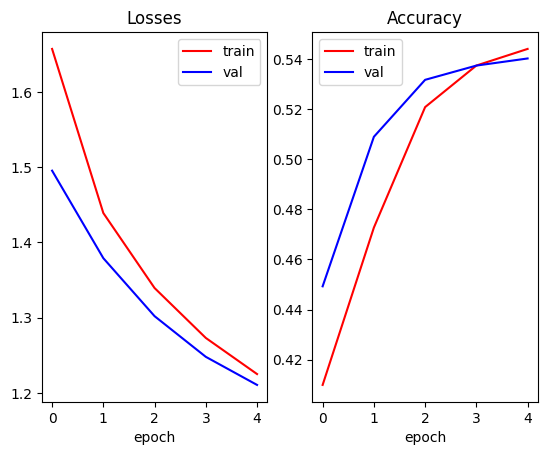

In [ ]:
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(model_name, rubert_tiny_transformer_model, epochs=5, freeze_backbone=True)

Valid accuracy: 0.5867


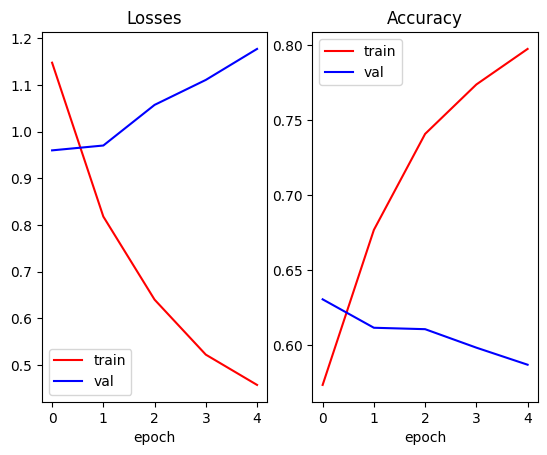

In [ ]:
rubert_tiny_transformer_model = TransformerClassificationModel(model_name) #...
rubert_tiny_full_finetuned = train_transformer(model_name, rubert_tiny_transformer_model, epochs=5, freeze_backbone=False)

### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

Результаты моделей очень близки, что любопытно, потому что руберт имеет всего три блока против 12 у mathbert. То есть, увеличение числа блоков не дает явного выигрыша.
Наибольшие различия в результатах определялись тем, был ли заморожен backbone или нет. Размороженный всегда дает результат на валидации лучше, однако в ходе обучения его точность снижается. Вероятно, он начинает переобучаться, это можно исправить использованием только одной эпохи и подбором оптимальных гиперпараметров.

Valid accuracy: 0.5441


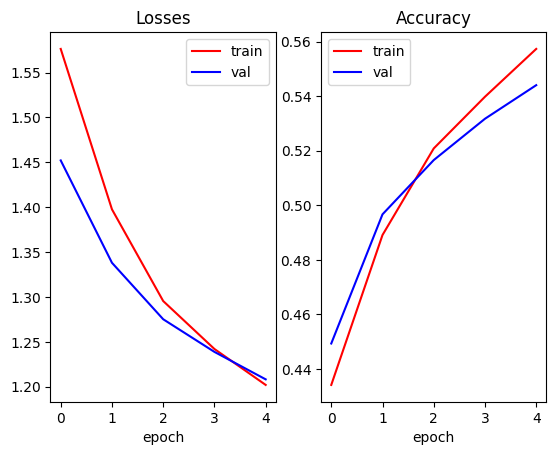

In [ ]:
### YOUR CODE IS HERE (probably, similar on the previous step)
model_name = "tbs17/MathBert"

mathbert_transformer_model = TransformerClassificationModel(model_name) #...
mathbert_finetuned_with_freezed_backbone = train_transformer(model_name ,mathbert_transformer_model, epochs=5, freeze_backbone=True)

In [ ]:
gc.collect()
torch.cuda.empty_cache()

Valid accuracy: 0.5791


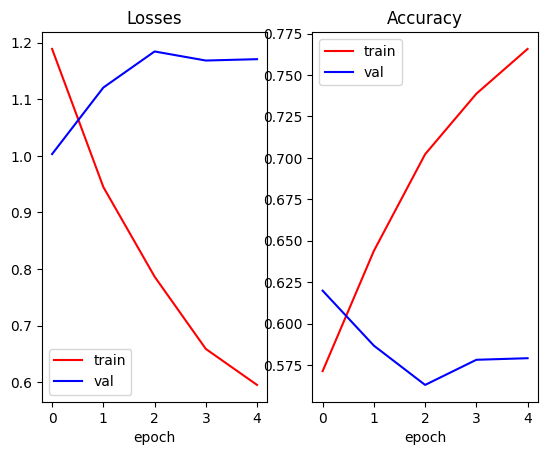

In [ ]:
mathbert_transformer_model = TransformerClassificationModel(model_name) #...
mathbert_full_finetuned = train_transformer(model_name, mathbert_transformer_model, epochs=5, freeze_backbone=False)

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [ ]:
import seaborn as sns

def draw_first_layer_attention_maps(model_name: str, model: TransformerClassificationModel, language: str, texts=short_tasks, device=device): # attention_head_ids: List, text_numbers: list
    model = model.to(device)
    model.eval()

    with torch.no_grad():
      for text in texts[language]:

        tokenizer = tokenizers[language]


        sentence = tokenizer(
              text,
              truncation=True,
              padding='max_length',
              max_length=max_length,
              return_tensors='pt'
          ).to(device)

        text_sentence = tokenizer.convert_ids_to_tokens(sentence["input_ids"][0])
        tokenized_sentence_len = text_sentence.index('[SEP]') + 1


        output, attention = model(**sentence)
        first_layer_attention = attention[0][0].cpu().detach().numpy() # [n heads, query len, key len]
        n_rows = 6
        n_cols = 2


        n_heads = len(first_layer_attention) #12

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, 24)) # снизить бы в 1,5-2 раза
        fig.suptitle(f'Attention Map for {model_name}\n Text: {text} \n\n')

        for i in range(n_heads):

            _attention_full = first_layer_attention[i]
            _attention = _attention_full[:tokenized_sentence_len, :tokenized_sentence_len]

            row = i // n_cols
            col = i % n_cols


            #plt.figure(figsize=(5, 4))
            sns.heatmap(_attention, ax=axes[row, col], xticklabels=text_sentence[:tokenized_sentence_len],
                        yticklabels=text_sentence[:tokenized_sentence_len], cmap="viridis", cbar=True)
            axes[row, col].set_title(f"Head {i}")
            ticks = [i + 0.5 for i in range(tokenized_sentence_len)]
            axes[row, col].set_xticks(ticks, text_sentence[:tokenized_sentence_len])
            axes[row, col].set_yticks(ticks, text_sentence[:tokenized_sentence_len])
            plt.tight_layout()
        fig.show()

        #fig.show()

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

In [ ]:
gc.collect()
torch.cuda.empty_cache()

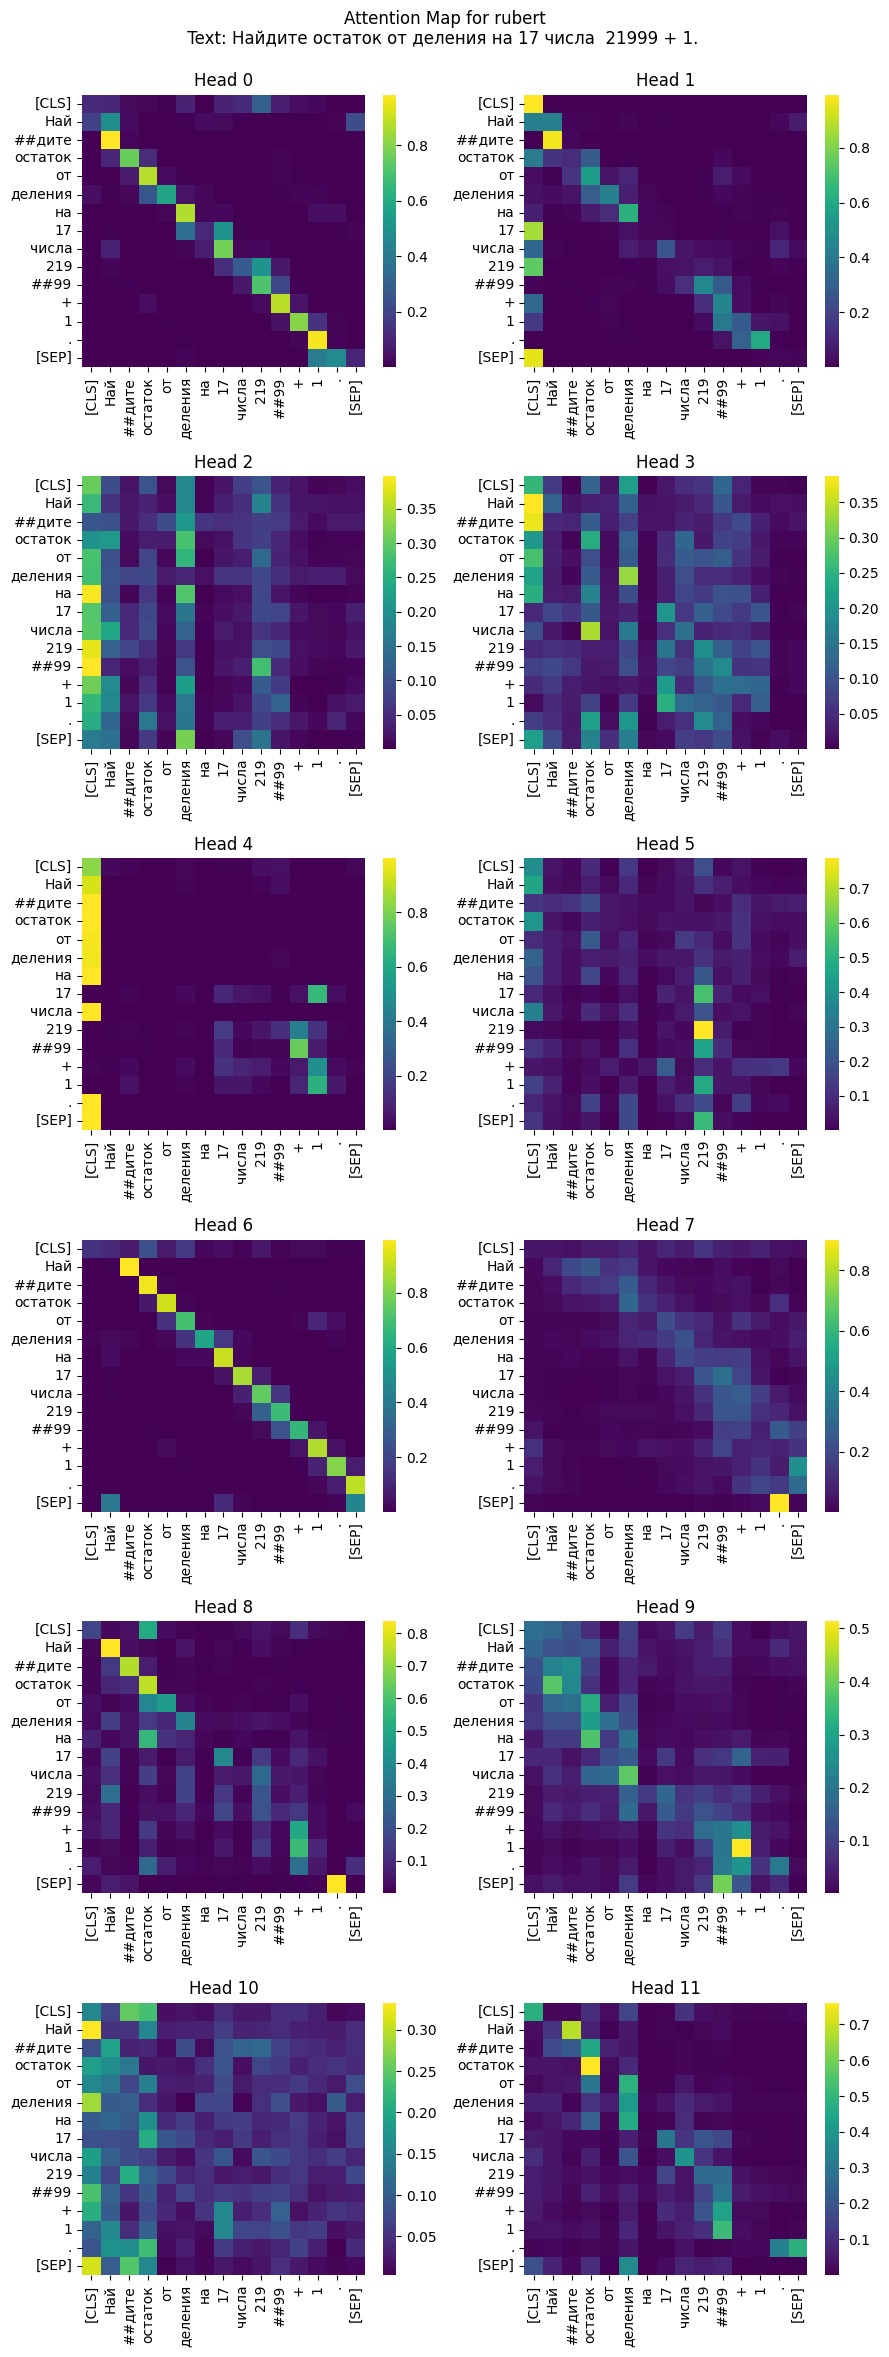

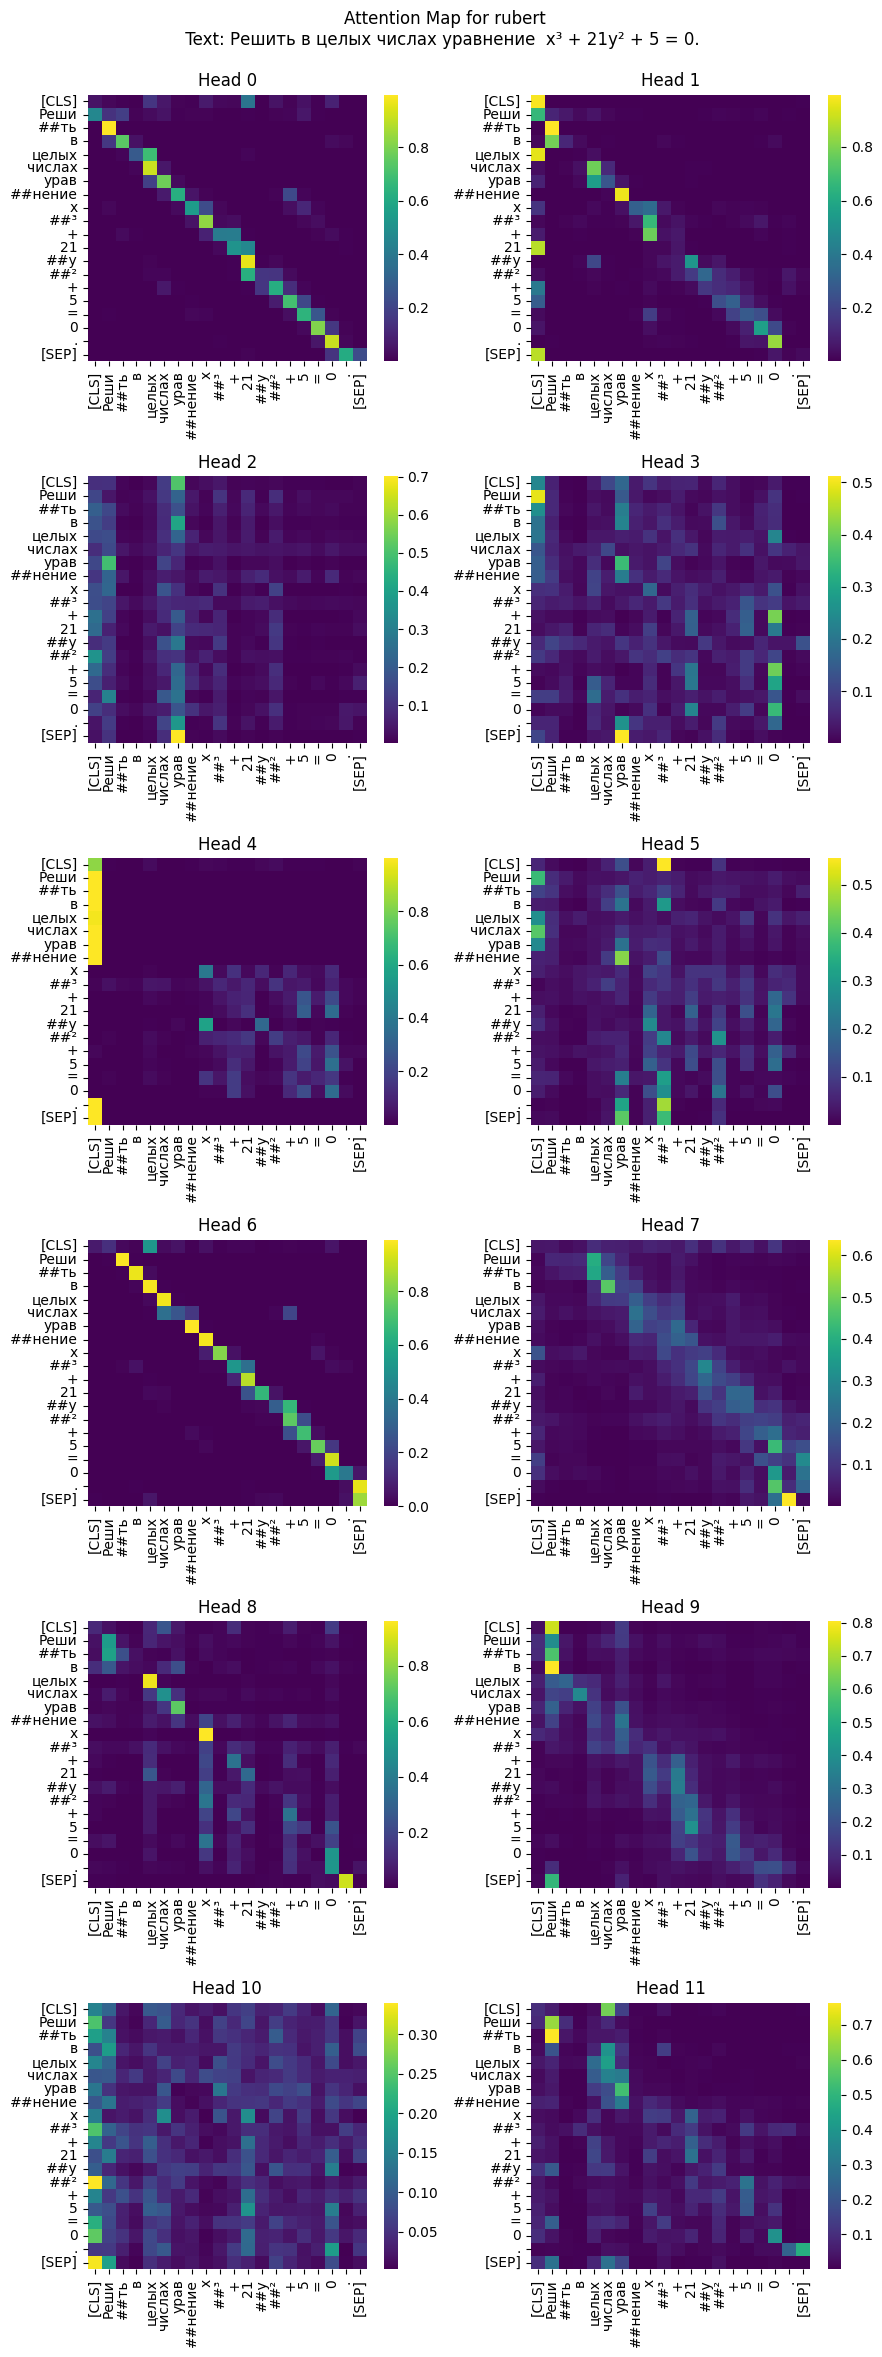

In [ ]:
draw_first_layer_attention_maps(model_name="rubert", model=rubert_tiny_transformer_model, language="ru")

Дя руберта наиболее информативны головы 0 и 6, на них видно четкое диагональное расположение больших значений пониже и повыше главной диагонали, соответственно. Так как горизонтальная ось отображает токены-ключи, а вертикальная - токены-запросы, эти головы отображают последовательность слов в предложении в обратном (голова 0) и прямом (голова 6) направлениях.
На головах 1, 7, 8 и 9 тоже прослеживаются дианональные паттерны, но они более размыты.

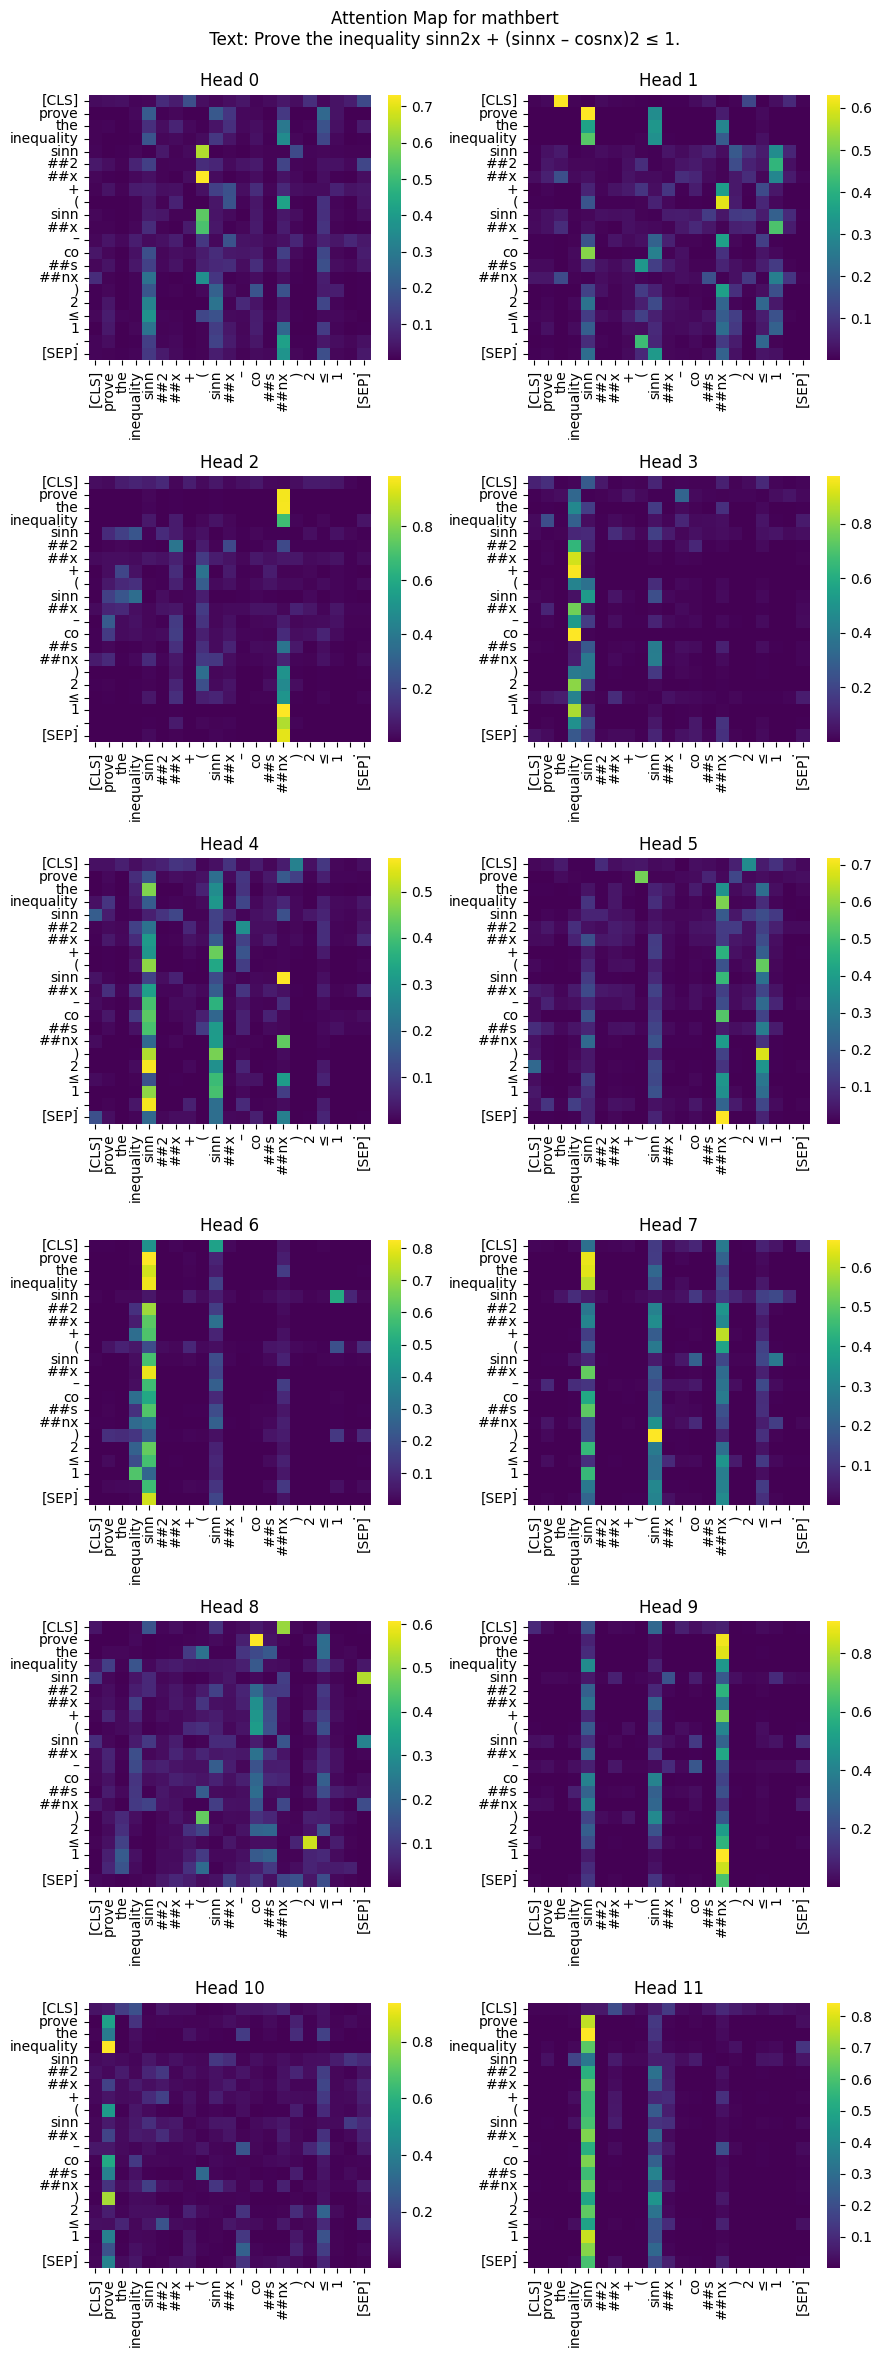

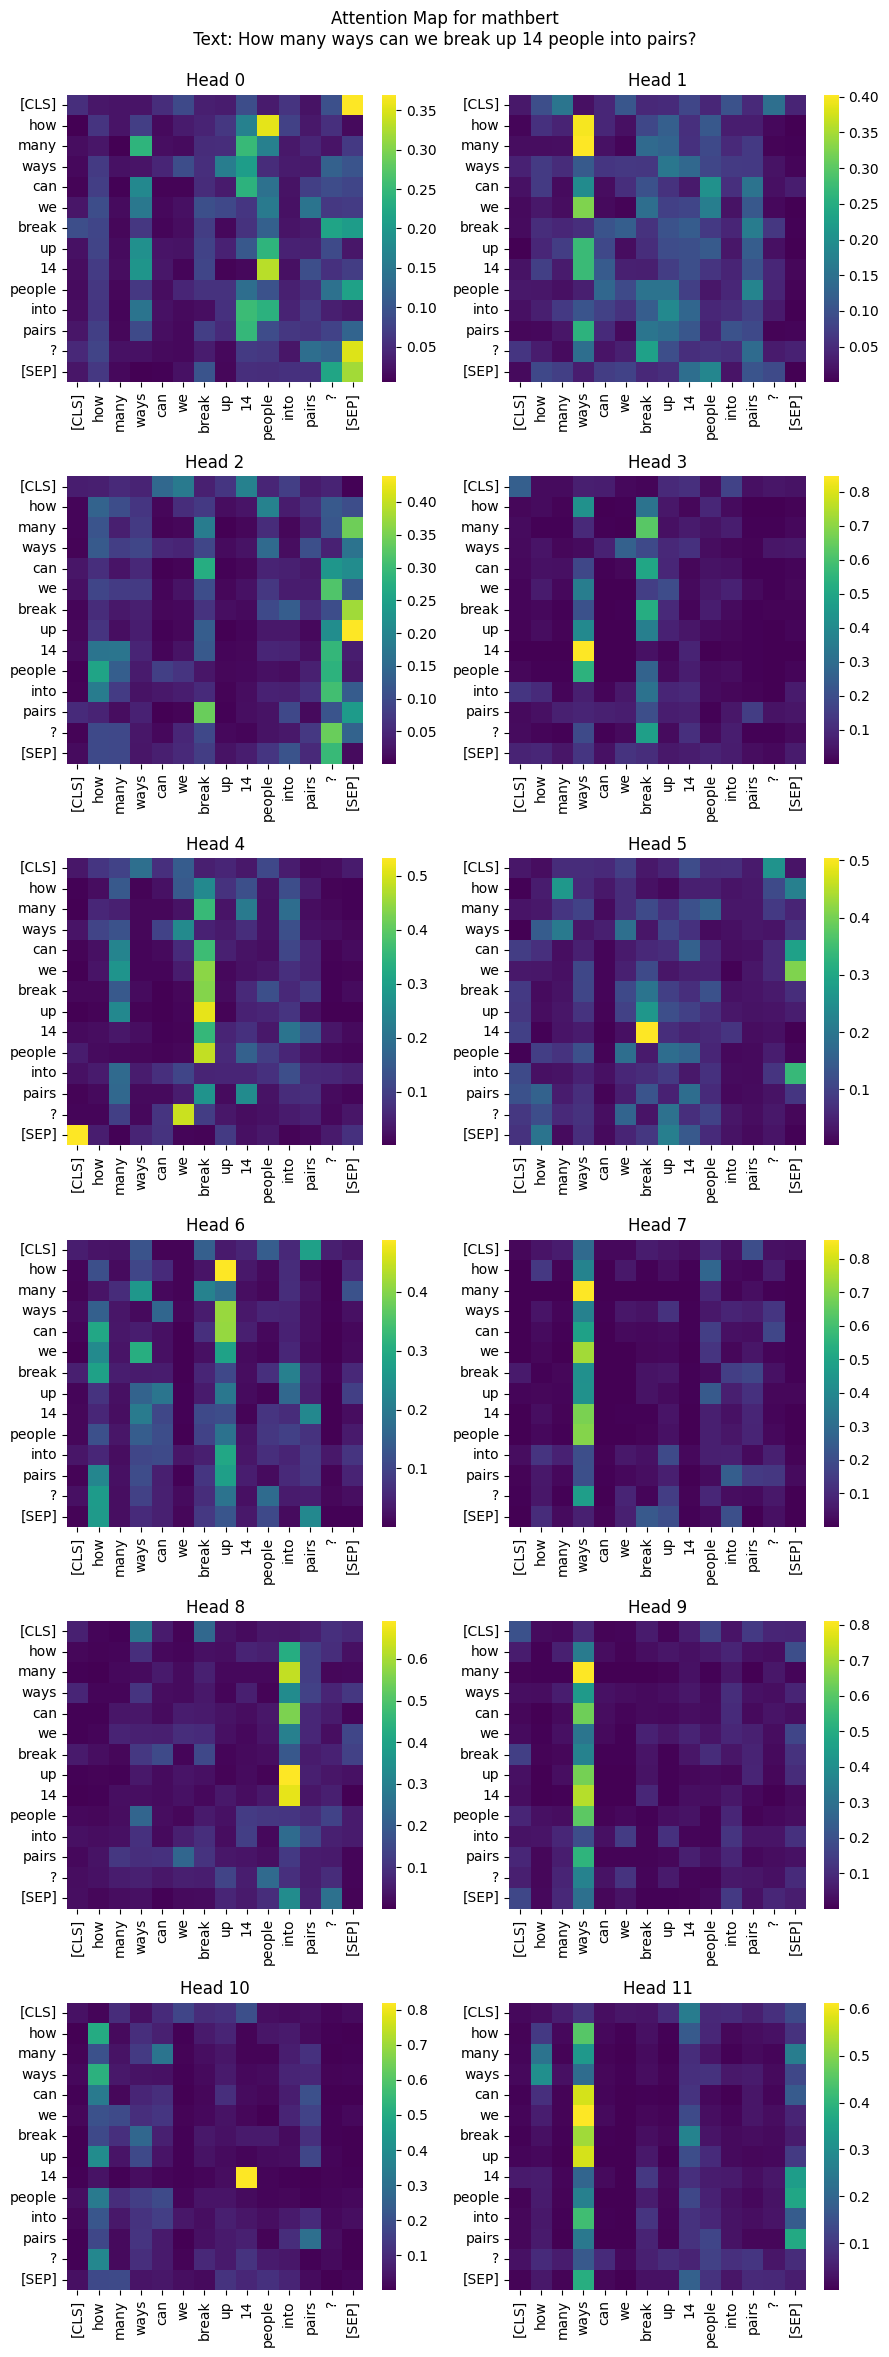

In [ ]:
draw_first_layer_attention_maps(model_name="mathbert", model=mathbert_transformer_model, language="en")

mathbert у тригонометрического выражения на некоторых картах выделяет синусы вертикальными полосами, а у задачи по комбинаторике - слово "ways" (карты 7, 9 и 11). Наверное, это связано с тем, что эту модель, в отличие от руберта, тренировали на математических текстах, поэтому она придает большое значение терминам. Интересно, что диагоналей, как в руберте, тут не наблюдается.

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

In [ ]:
### YOUR CODE IS HERE

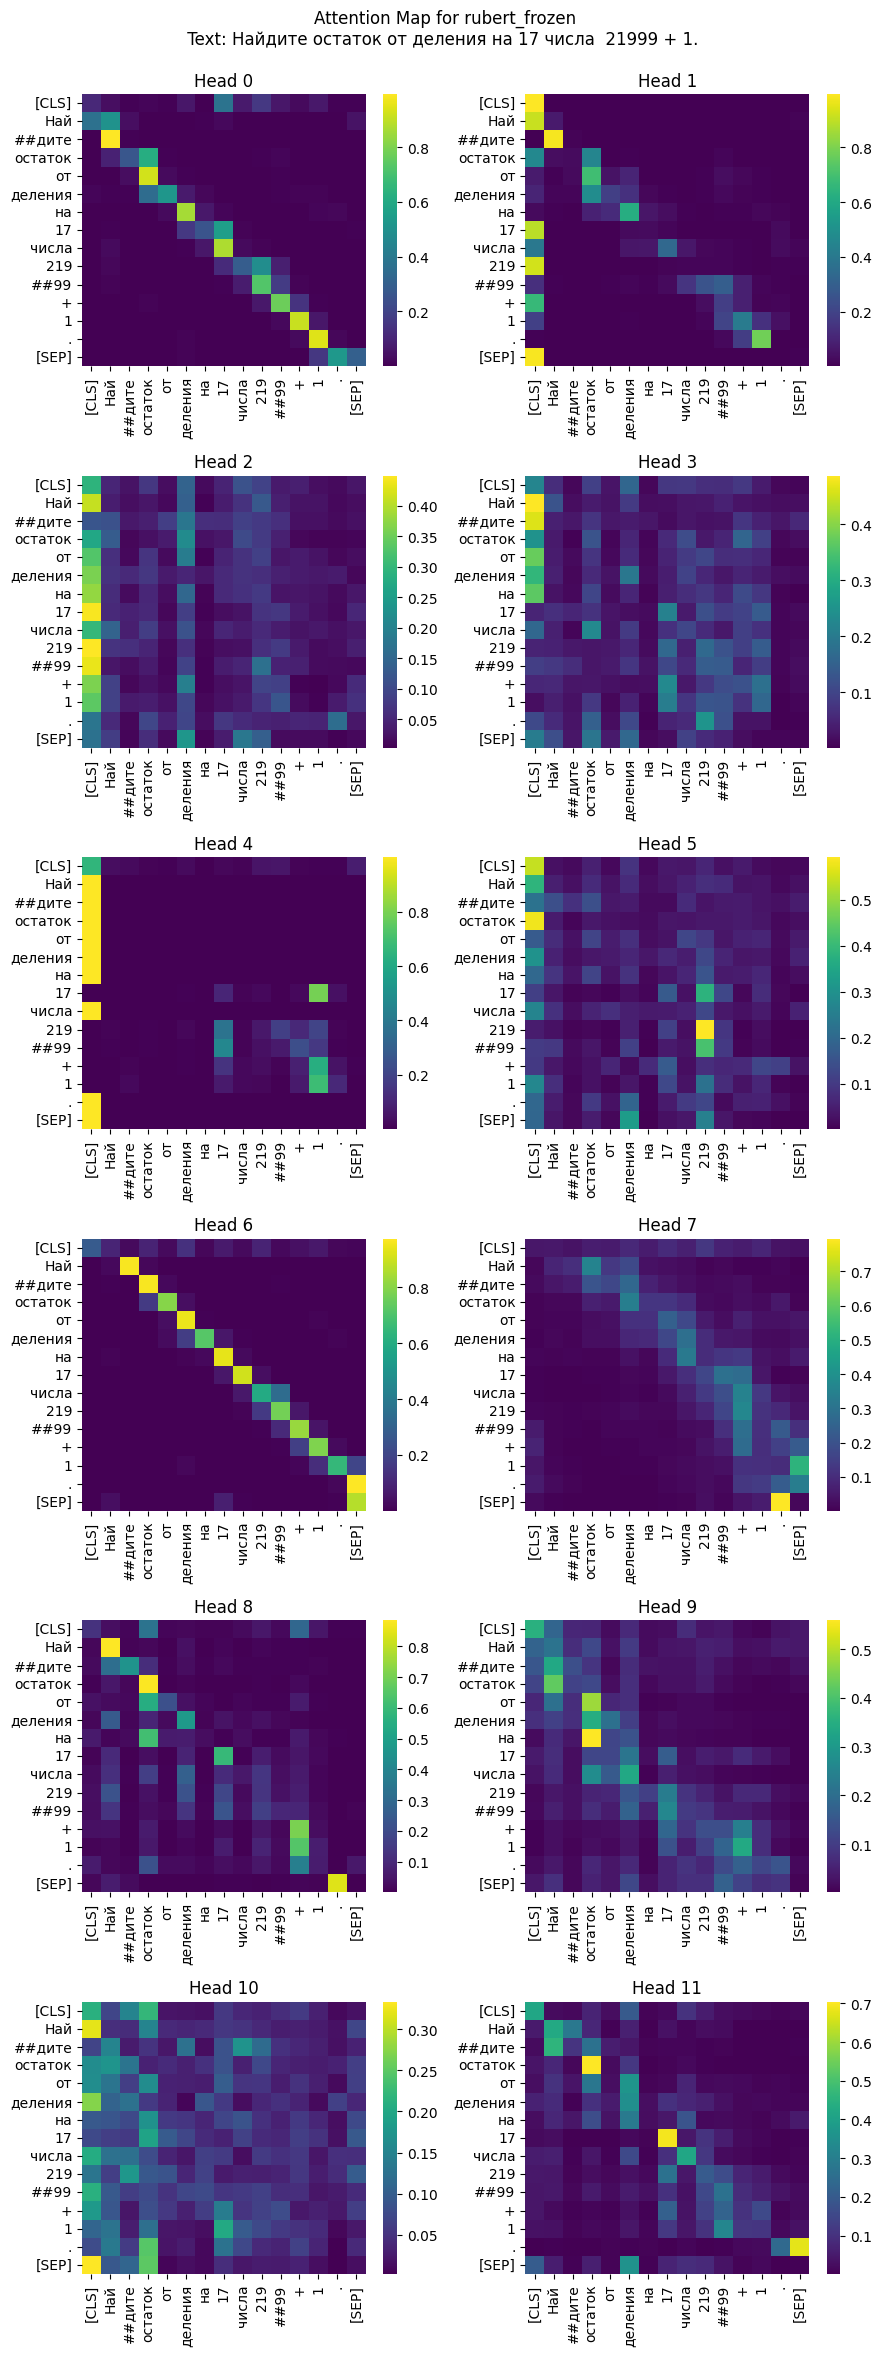

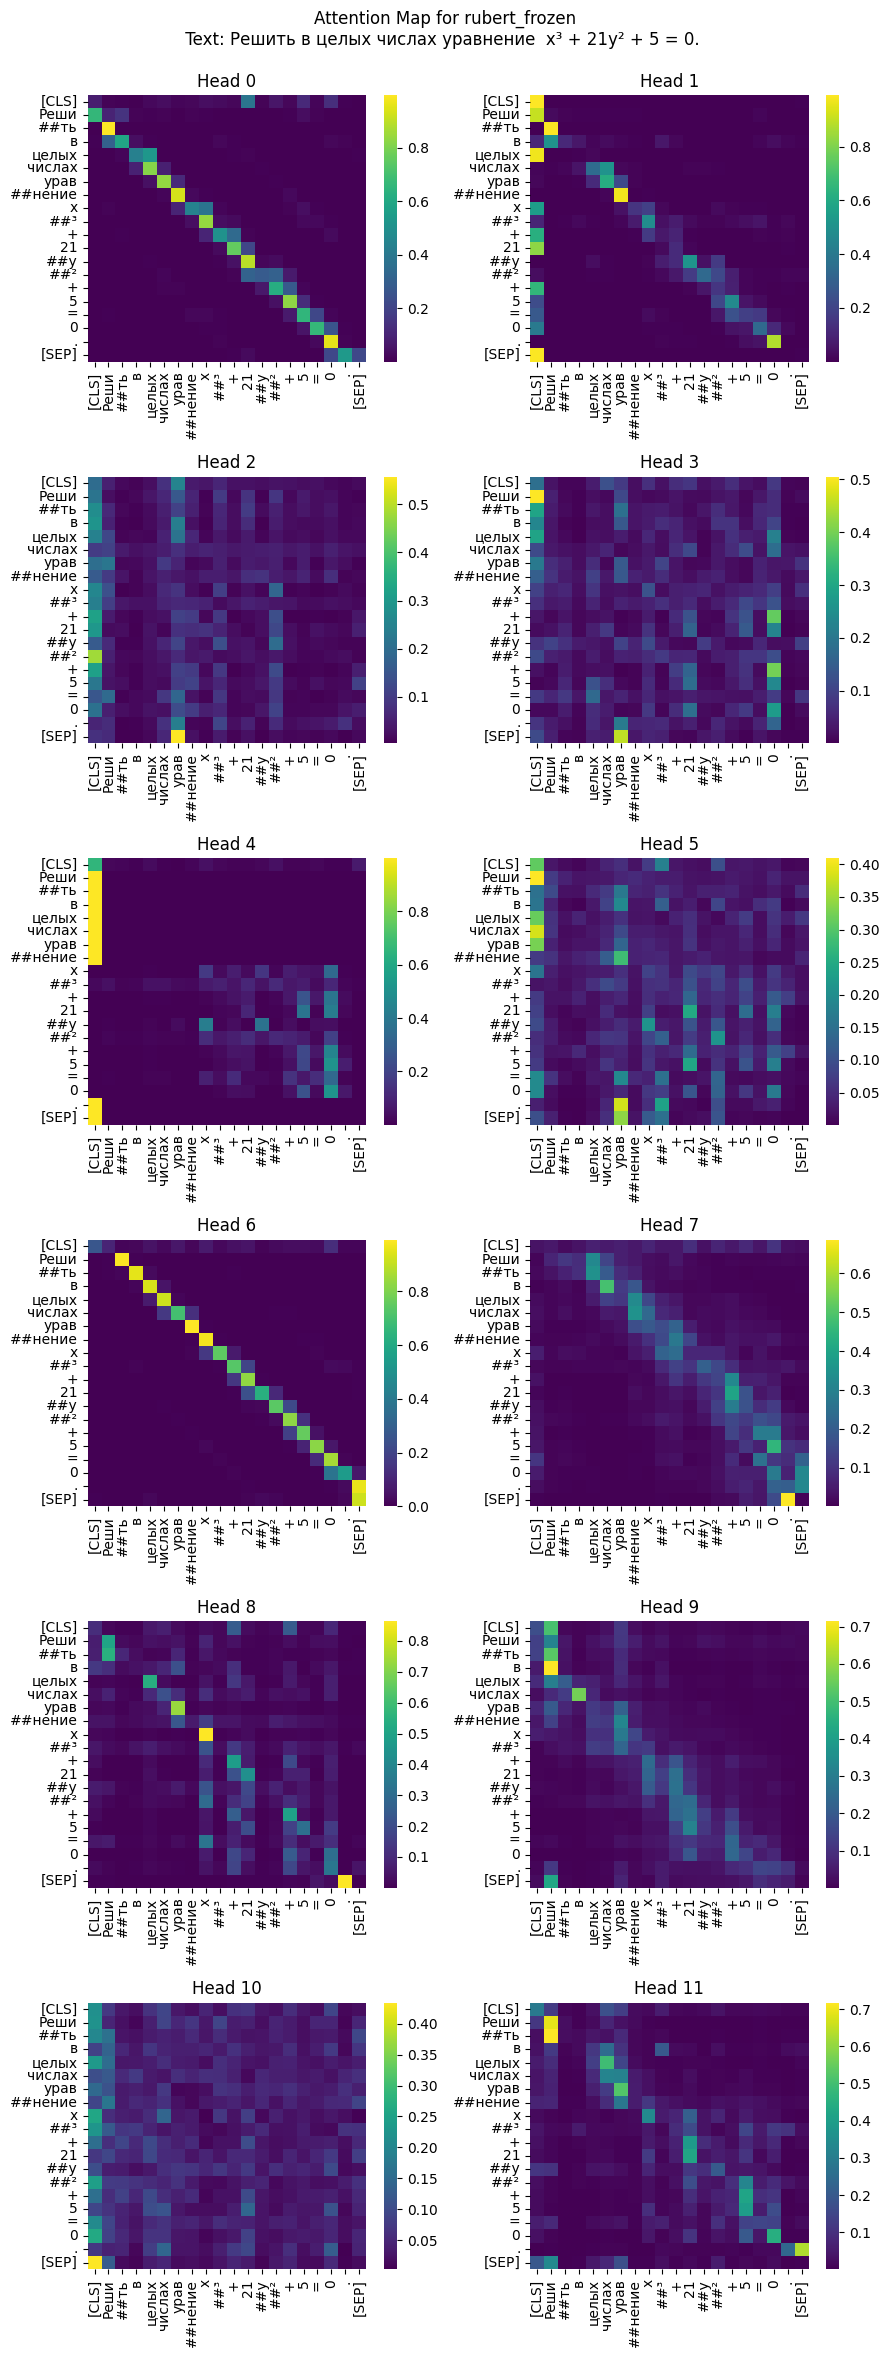

In [ ]:
draw_first_layer_attention_maps(model_name="rubert_frozen", model=rubert_tiny_finetuned_with_freezed_backbone, language="ru")

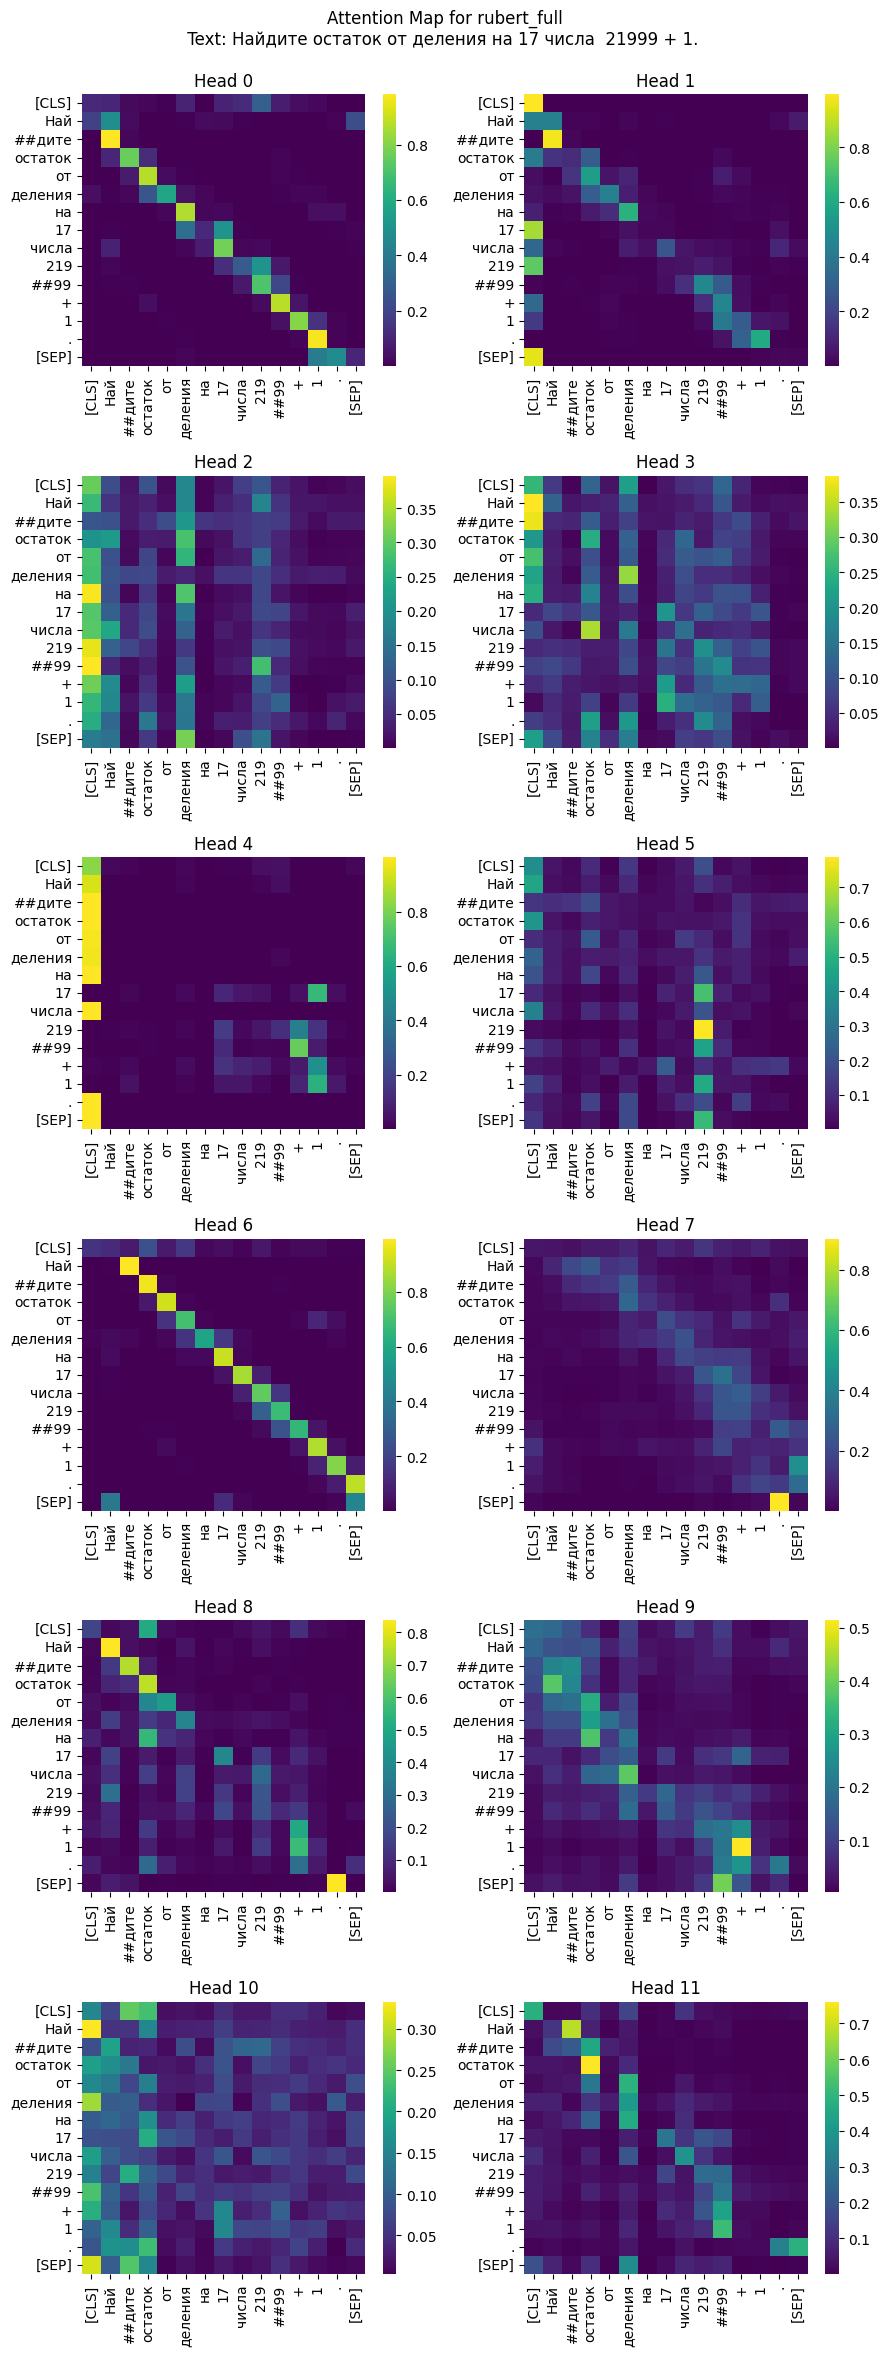

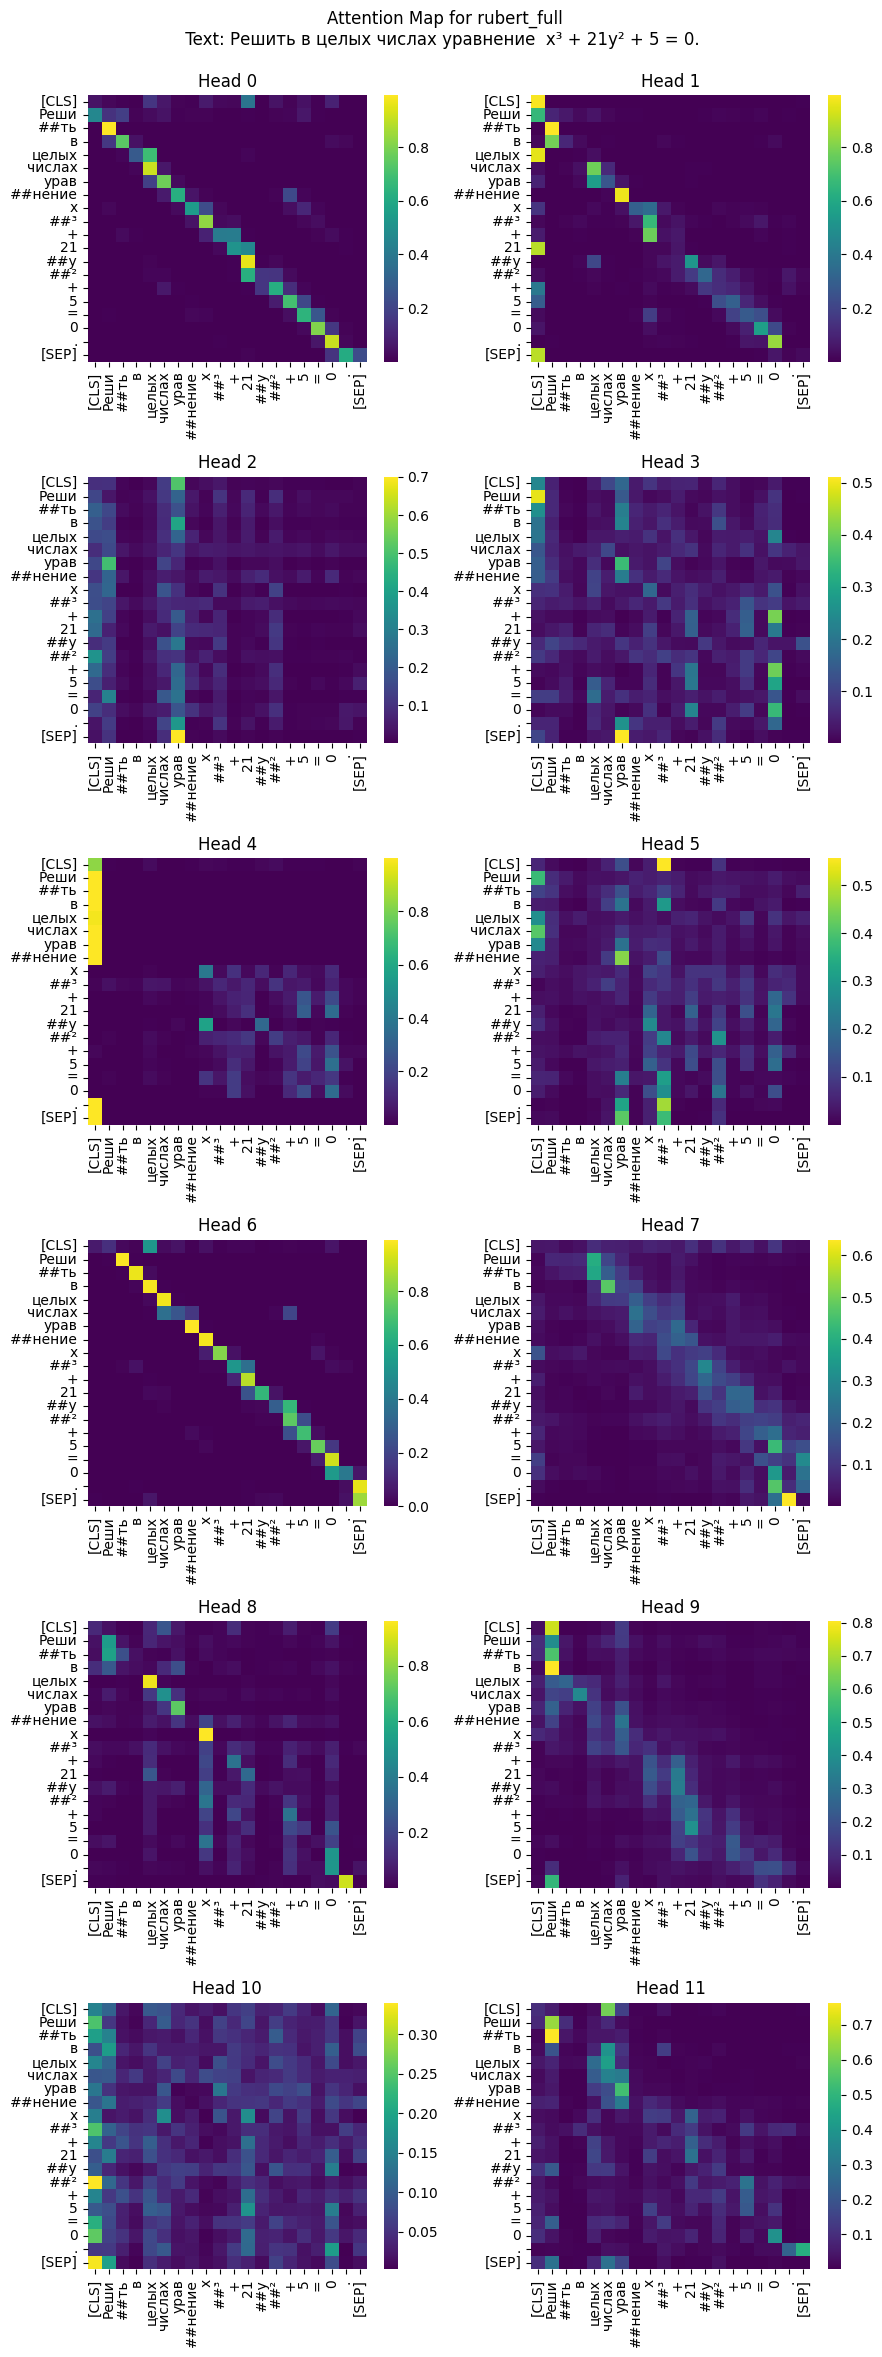

In [ ]:
draw_first_layer_attention_maps(model_name="rubert_full", model=rubert_tiny_full_finetuned, language="ru")

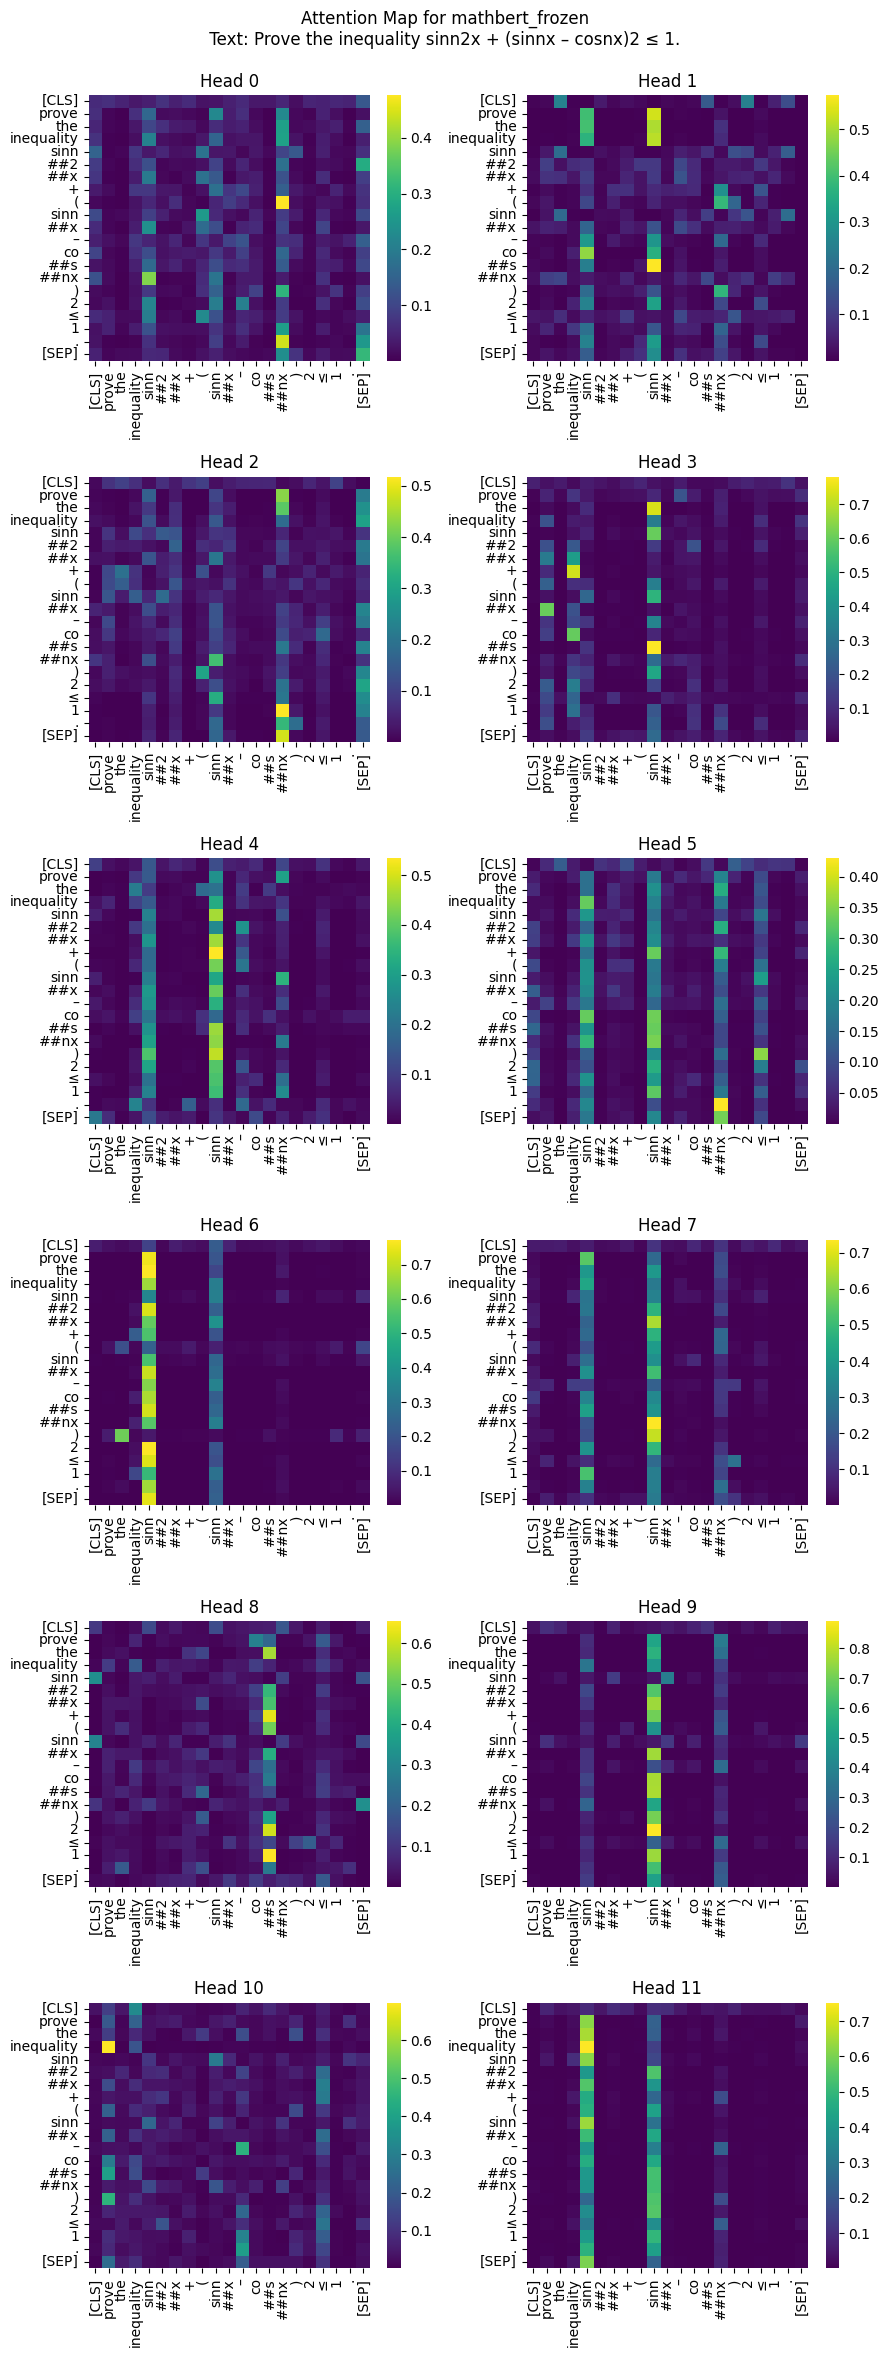

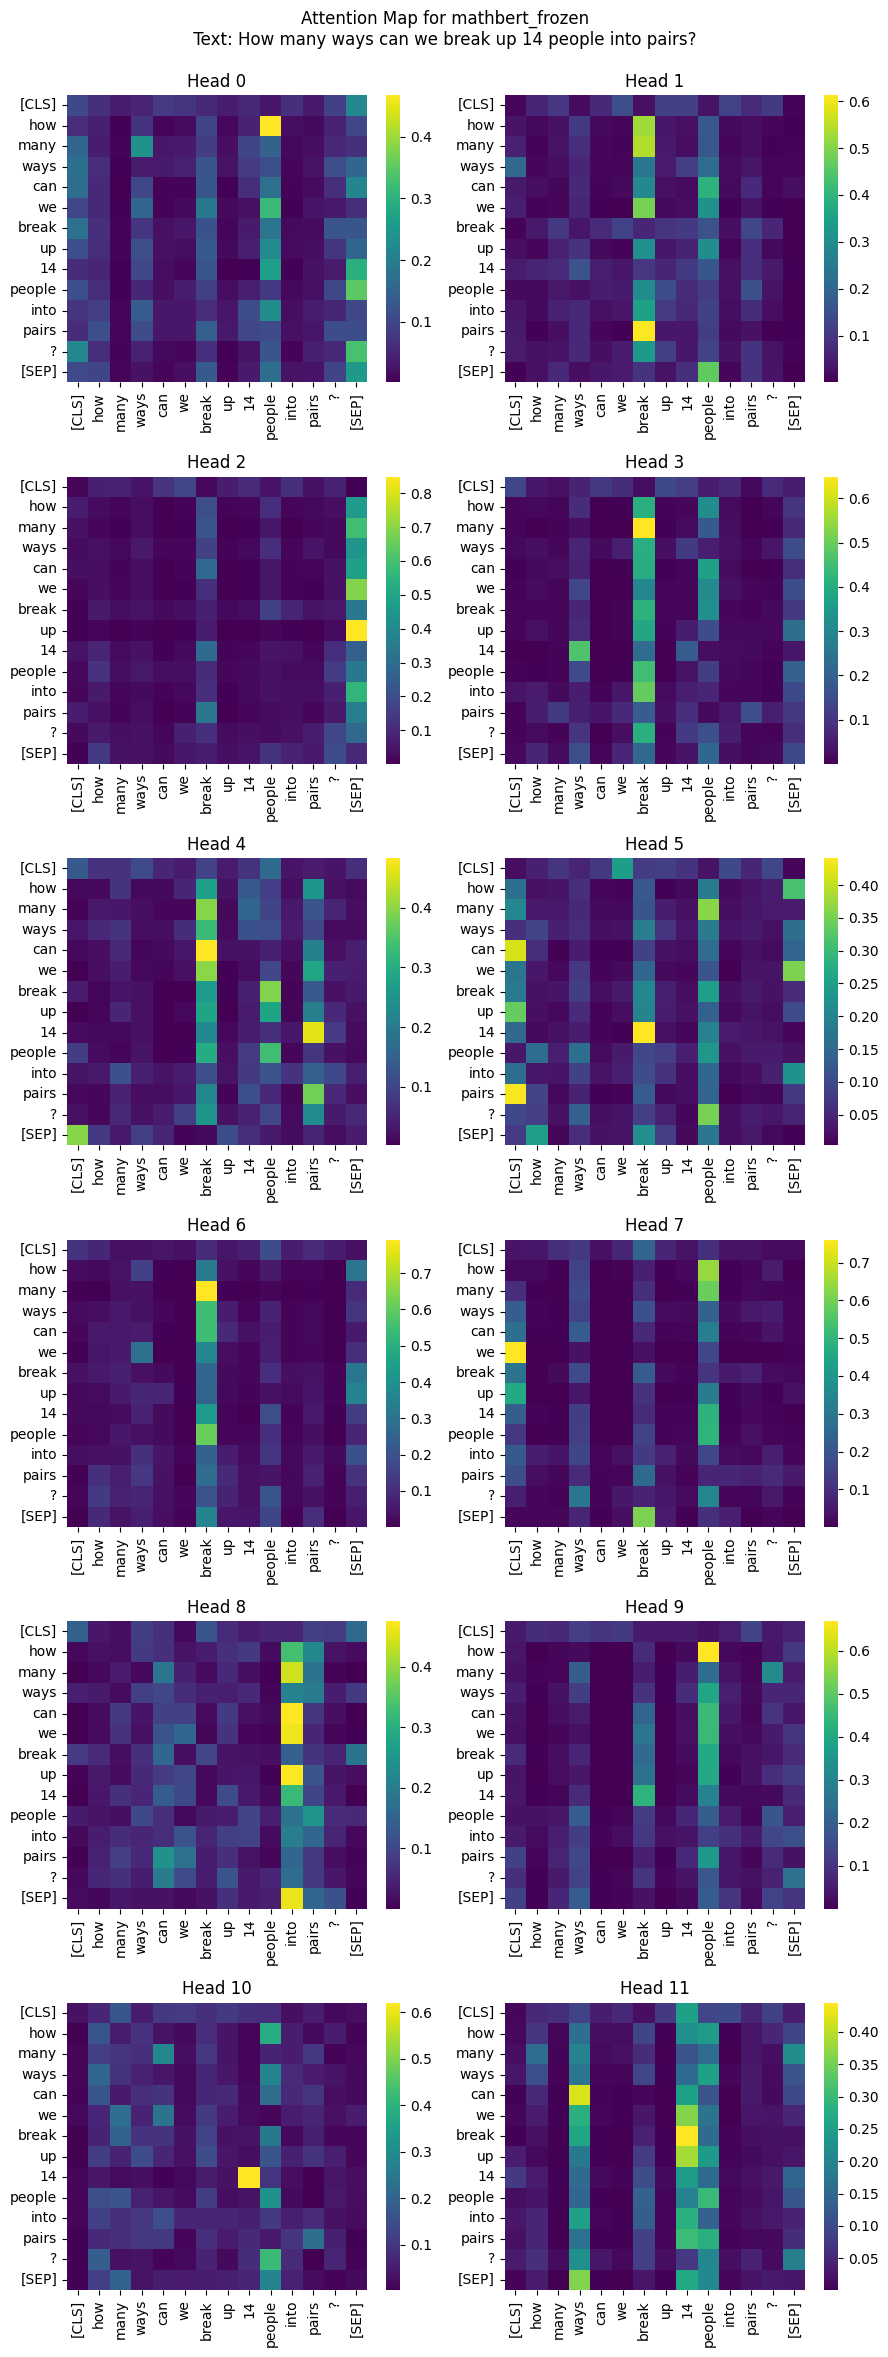

In [ ]:
draw_first_layer_attention_maps(model_name="mathbert_frozen", model=mathbert_finetuned_with_freezed_backbone, language="en")

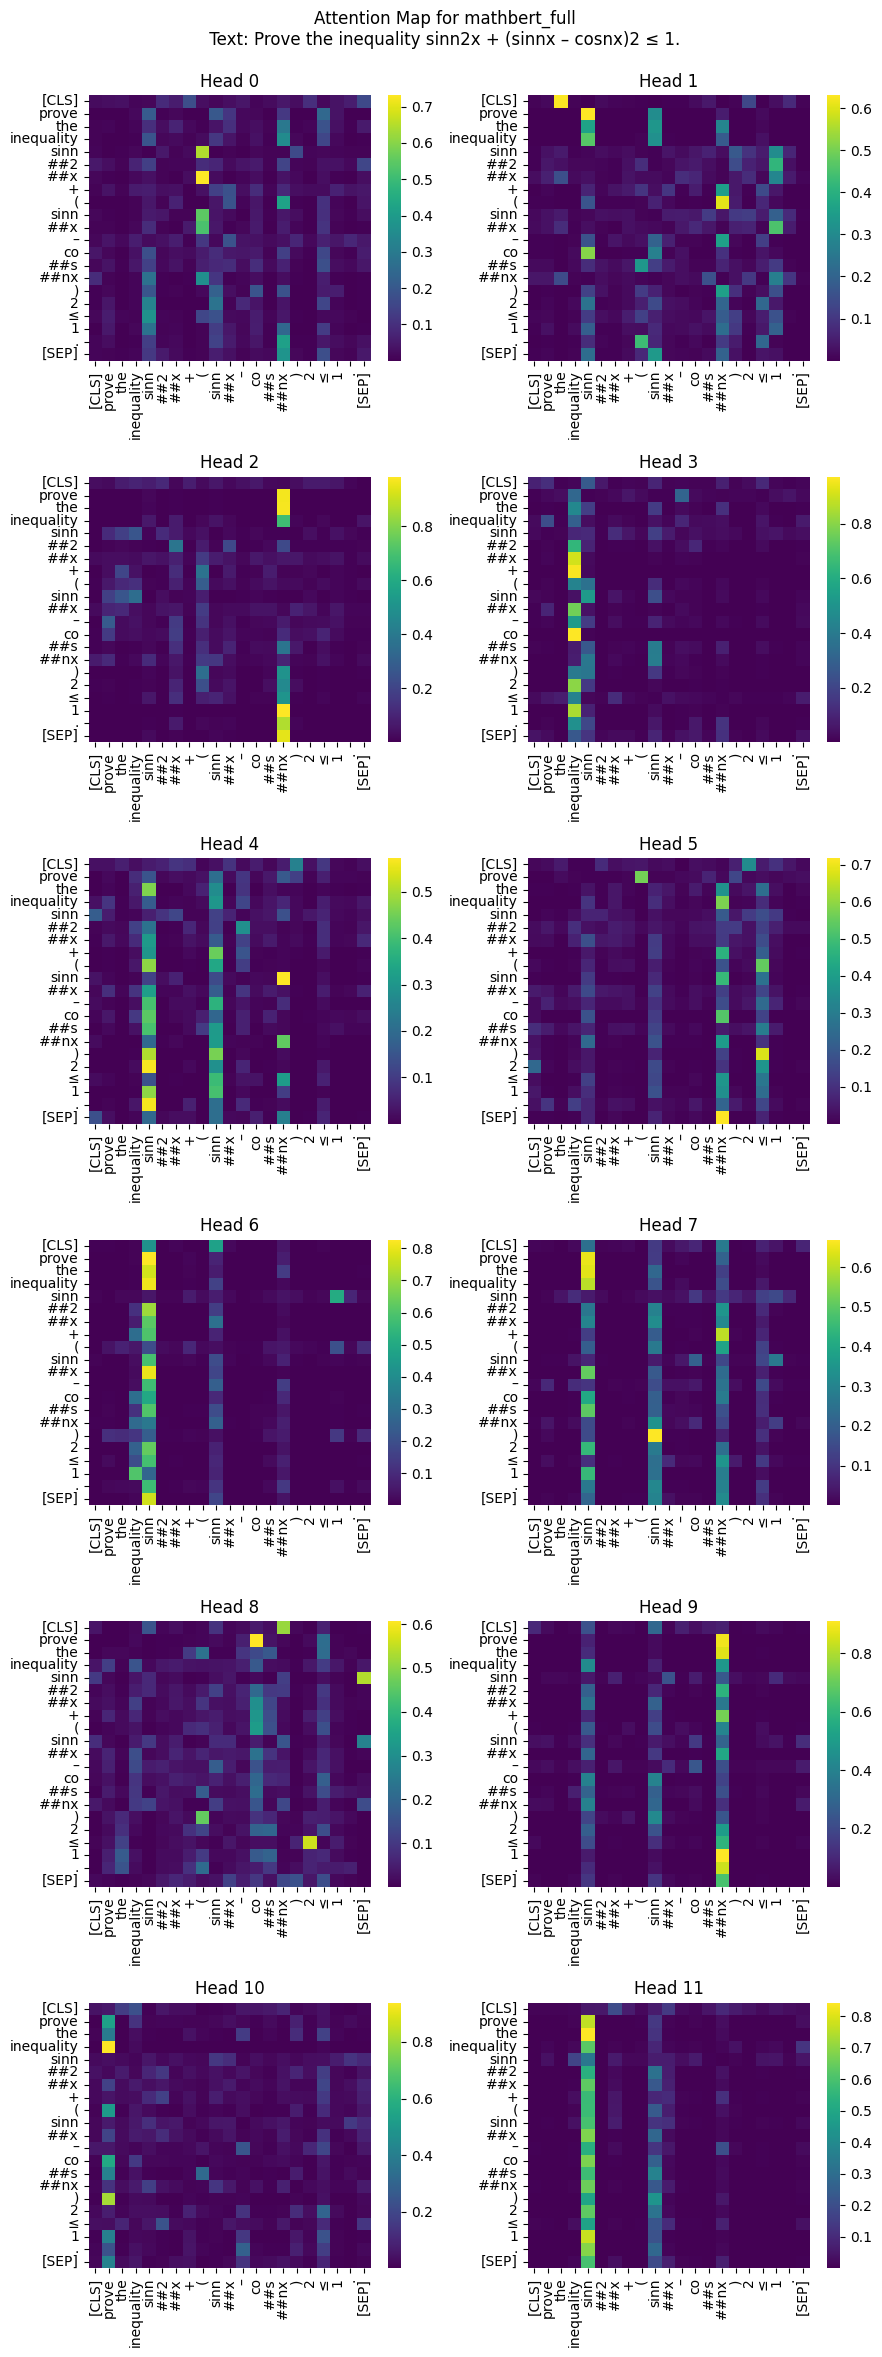

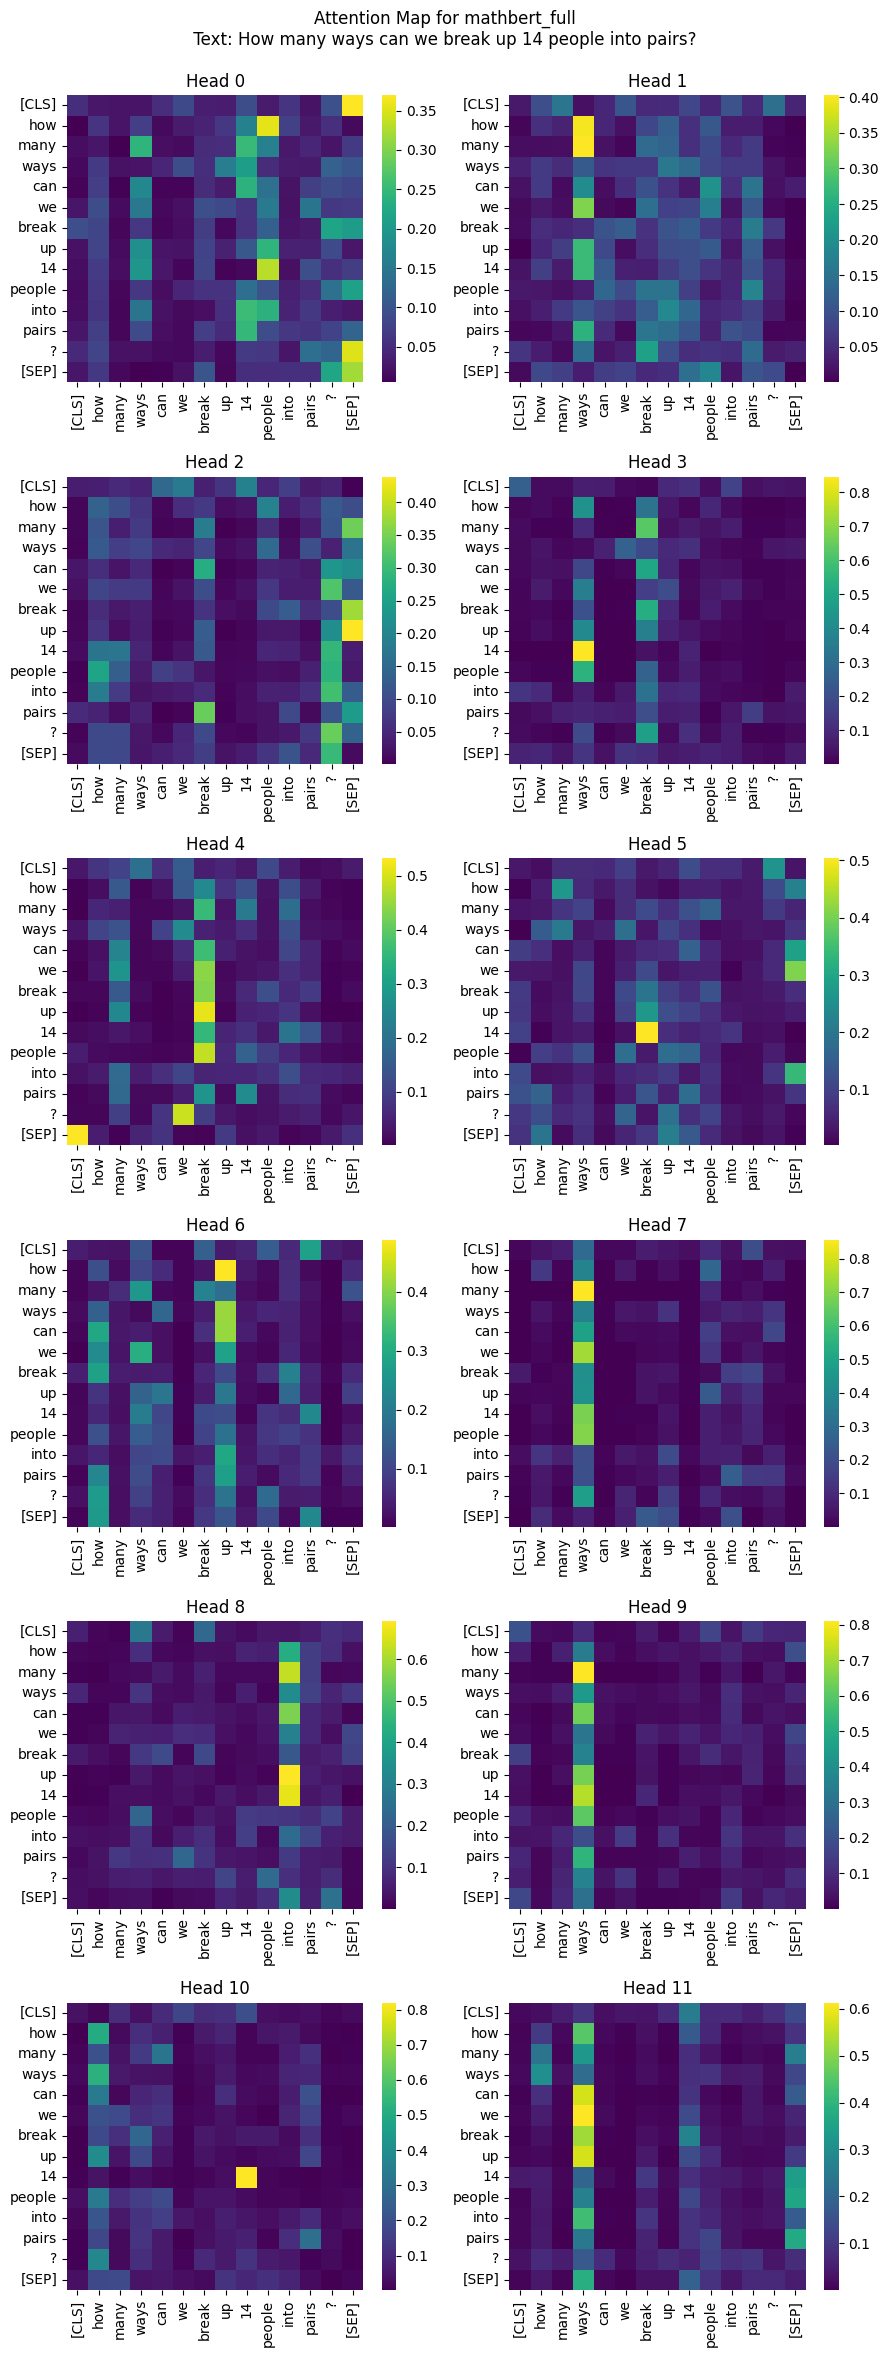

In [ ]:
draw_first_layer_attention_maps(model_name="mathbert_full", model=mathbert_full_finetuned, language="en")

Можно заметить, что дообучение только классификационного слоя моделей не влияет на слои внимания, что очевидно. Дообучение полных моделей не меняет общий вид карт внимания первого слоя, но значения некоторых элементов карт незначительно изменяются.

Отсутствие серьезных изменений при дообучении я бы объяснил тем, что изначальные модели уже хорошо обучены находить в текстах закономерности, и значительное изменение их весов внимания привело бы к сильному ухудшению результатов и росту лосса. Возможно, в том числе поэтому, из-за изменений слоев внимания, лосс в моих дообучениях размороженных моделей и увеличивался.